In [597]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp

import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [598]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimisers import *

import elements 
import importlib
importlib.reload(elements)


<module 'elements' from '/Users/matteogiacomelli/Documents/Technical_Student/simulation/Knobs in LSS4 SPS/elements.py'>

In [599]:
line = initialise_line()
rematch_optics(line, tune = 24.39)



Loading line from dict:   0%|          | 0/4492 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4492 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4495 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4497 [00:00<?, ?it/s]

Non-channeled particle not lost during tracking.
The line already has an associated tracker
Channeled particle not lost during tracking.
Blocking elements encountered:
Empty DataFrame
Columns: [Position, Element Name, max_x, min_x]
Index: []
                                             
Optimize - start penalty: 31.68                             
Matching: model call n. 19 penalty = 1.4976e-09              
Optimize - end penalty:  1.49759e-09                            
Target status:               nalty = 1.4976e-09              
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True   5.00862e-11         24.39         24.39 'qx', val=24.39, tol=1e-05, weight=10
1  ON    qy     True   1.41135e-10         24.37         24.37 'qy', val=24.37, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kq

(<xtrack.match.OptimizeLine at 0x144592bd0>,
 <xtrack.match.OptimizeLine at 0x14bbe67d0>)

In [600]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')


In [601]:
blocking_elements = open_blocking_apertures(line, TECA, deltaP_P)
import elements 
import importlib
importlib.reload(elements)

remove_ZS_apertures(line)
remove_inner_sideLimits_closeTECA(line)

save_df_Limit_elements_features(line)

The line already has an associated tracker
Non-channeled particle not lost during tracking.
The line already has an associated tracker
Channeled particle not lost during tracking.
Blocking elements encountered:
Empty DataFrame
Columns: [Position, Element Name, max_x, min_x]
Index: []


,Position,Element Name,max_x,min_x


In [602]:
import optimisers as op
import importlib
importlib.reload(op)

# Set the initial conditions
opt = horizontal_bumpLSS4(line)

opt.log()
opt.solve()

line.vv["extr_bump_knob"] = 2.04   # MAXIMAL OBTAINABLE! LEAVE IT LIKE THIS, CHANGE IT IN THE CELL BELOW

bump_closed_orbite = ensure_bump_closed(line)

bump_closed_orbite.log()

bump_closed_orbite.step(10)
bump_closed_orbite.target_status()
bump_closed_orbite.vary_status()
knobs_after_closingOrbit = bump_closed_orbite.get_knob_values()
knobs_after_closingOrbit = bump_closed_orbite.get_knob_values(iteration=0)


                                             
Optimize - start penalty: 0.3591                            
Matching: model call n. 19 penalty = 4.9973e-16              
Optimize - end penalty:  4.99734e-16                            
                                             
Optimize - start penalty: 4.997e-16                          
Matching: model call n. 21 penalty = 4.9973e-16              
Optimize - end penalty:  4.99734e-16                            
                                             
Optimize - start penalty: 0.2631                            
Matching: model call n. 45 penalty = 2.2460e-14              
Optimize - end penalty:  2.24603e-14                            
                                             
Optimize - start penalty: 2.246e-14                          
Matching: model call n. 47 penalty = 2.2460e-14              
Optimize - end penalty:  2.24603e-14                            
Target status:               nalty = 2.2460e-14              


In [603]:
tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d")
# tw = tw.to_pandas()
# tw.index = tw.name

# Knobs for the LSSs

In [604]:
tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.2.*"].cols["k0l"]

bumpersLSS2 = list(line.vars.get_table().rows["kmp.h2.*[0-9]"].name)
bumpersLSS4 = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)

### Don't rerun the following cell

In [605]:
for bumper in bumpersLSS2:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

kmplh21431 0.0009700921440945365
kmplh21995 0.0007025020936683378
kmplh22195 -0.0006119387110960107
kmpnh21732 0.0005978427676110134
kmpsh21202 5.699451657809536e-05
kmpsh41402 5.911840045008408e-05
kmplh41658 -0.0006963316559666893
kmplh41994 -0.00038296773232349466
kmpsh42198 -0.00034881862316492605


# Max values of the strength of the correctors (it is needed to divide this value by the beam rigidity)

kmplh21431 1.892 at 400A
kmplh21995 1.892 at 400A
kmplh22195 1.892 at 400A
kmpnh21732 2.2251 at 505A
kmpsh21202 0.97 at 400A
kmpsh41402 0.97 at 400A
kmplh41658 1.892 at 400A
kmplh41994 1.892 at 400A
kmpsh42198 0.97 at 400A

In [ ]:
1.892 / 1333   ### LIKE THIS IS MILLIRAD

0.0014193548387096773

## The following cell changes the knobs!!

In [606]:
# KNOBS FOT LSS2 AND LSS4, # CHANGE THESE VALUES TO CHANGE THE BUMP

line.env["extr_bump_knob"] = 0.905 ## OPTIMAL FOR EXTRACTION
line.env["x_teca_knob"] = 1.01  ## OPRIMAL FOR EXTRACTION

In [607]:
for bumper in bumpersLSS2:
    line.vv[bumper] = bumper + "_init" + "*  extr_bump_knob"
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.vv[bumper] = bumper + "_init" + "*  x_teca_knob"
    print(bumper, line.vv[bumper])

kmplh21431 0.0008779333904055556
kmplh21995 0.0006357643947698456
kmplh22195 -0.0005538045335418897
kmpnh21732 0.0005410477046879672
kmpsh21202 5.15800375031763e-05
kmpsh41402 5.970958445458492e-05
kmplh41658 -0.0007032949725263561
kmplh41994 -0.0003867974096467296
kmpsh42198 -0.0003523068093965753


# Time dependent extration

### Installing the septa to extract the particles

In [608]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)
print(septa_names_with_apertures)

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']


Generating particles

In [609]:
n_part = 300



x_norm   = np.random.normal(loc = 0, scale = 1, size=n_part)
px_norm =  np.random.normal(loc = 0, scale = 1, size=n_part)  # in between being channeled and not
#x_norm  = TECA.jaw * np.ones(n_part)
#px_norm = TECA.tilt * np.ones(n_part)
y_norm, py_norm = np.zeros(n_part), np.zeros(n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * deltaP_P

line.build_tracker()

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
#tw_lss2 = tw.rows['TECA.entry':'_end_point']

tw_lss2 = tw.rows[:]


The line has collective elements.
In the twiss computation collective elements are replaced by drifts


# Introducing a time dependent energy increase

In [ ]:
line.discard_tracker()

num_turns = 500

# Define the momentum increment per turn (Δp₀c)
#delta_p0c =  2000e9 / 10 * 23e-6  # Example: 450 GeV over 10 s with 23 μs revolution time
delta_p0c = 0.6e9 / num_turns  # THE SPS ENERGY CAN GO UP TO 400.6 GeV SO I ASSUME 0.6 GeV DIVIDED BY 100 TURNS

# Create the ReferenceEnergyIncrease element
energy_increase = xt.ReferenceEnergyIncrease(Delta_p0c=delta_p0c)

# Append the energy increase element to the end of the line
line.append_element(energy_increase, name='energy_increase')

<Line  at 5628318800>

### Inserting monitors at each element

In [611]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
#tw_lss2_df = tw_lss2_df.loc['qd.20910':'qda.21910'] 
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

line.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=100, num_particles=particles._capacity, every_n_turns=1)
    line.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1) 
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    

### Inserting the crystals

In [612]:
line.discard_tracker()
line.insert_element("extraction.crystal.TECS", TECS, at_s=line.get_table()['s', 'tecs.21602'] )
line.insert_element("extraction.crystal.TECA", TECA, at_s = line.get_table()['s', 'TECA.entry'] )

Slicing line:   0%|          | 0/8592 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/8593 [00:00<?, ?it/s]

<Line  at 5628318800>

### Inserting the TCSM 

In [613]:
aperture = xt.LimitRect(
    min_x=-1,  # Lower x limit in meters
    max_x=0.005,   # Upper x limit in meters
    min_y=-1,  # Lower y limit in meters
    max_y=1    # Upper y limit in meters
)

# line.insert_element("TCSM aperture", aperture, at_s = line.get_table()['s', 'tcsm.51932.'] )  # remove the comment if you want to stop the channeled particles

# Time dependent tracking with evolving knobs

### Moving the blades of the MST septum

In [614]:
# Move the blade_position of 'mst.21794.sep' down by 1 mm
element_name = 'mst.21794.sep'
line[element_name].interaction_process.blade_position += 0.001  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21794.sep: 0.0434 m


In [615]:
element_name = 'mst.21774.sep'
line[element_name].interaction_process.blade_position += 0.001  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21774.sep: 0.04179 m


### Teacking

In [616]:
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu())

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
if np.any(particles.state < 1):
    lost_particles = np.where(particles.state < 1)[0]
    print(f"Particles lost during tracking: {len(lost_particles)}")
else:
    print("No particles lost during tracking")
record = line.time_last_track

Particles lost during tracking: 300


In [617]:
import numpy as np

# Get indices of lost particles
lost_particles = np.where(particles.state < 1)[0]

if len(lost_particles) > 0:
    print(f"Number of lost particles: {len(lost_particles)}")
    print("\nParticle loss locations:")

    # Get element names from the line
    element_names = line.element_names

    # Count losses per element
    loss_counts = {}
    for idx in lost_particles:
        lost_at = particles.at_element[idx]  # Index of element where the particle was lost
        lost_element_name = element_names[lost_at]
        loss_counts[lost_element_name] = loss_counts.get(lost_element_name, 0) + 1

    # Print where the particles were lost
    for element, count in loss_counts.items():
        print(f"{count} particles lost at element '{element}'")
else:
    print("No particles were lost during tracking")


Number of lost particles: 300

Particle loss locations:
275 particles lost at element 'tt20.extraction'
14 particles lost at element 'extraction.crystal.TECA'
9 particles lost at element 'tpst.21760_entry.sep'
2 particles lost at element 'mst.21774.sep'


### Saving the particles features that are lost at TPST collimator

In [618]:
# Find indices of lost particles at 'tpst.21760_entry.sep'
lost_at_tpst = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tpst.21760_entry.sep'
]

if lost_at_tpst:
    print("Particles lost at tpst.21760_entry.sep:")
    lost_info = []
    for idx in lost_at_tpst:
        x_val = particles.x[idx]
        px_val = particles.px[idx]
        dpp_val = particles.delta[idx]
        lost_info.append({'idx': idx, 'x': x_val, 'px': px_val, 'dpp': dpp_val})
        print(f"Particle {idx}: x = {x_val:.6e}, px = {px_val:.6e}, dpp = {dpp_val:.6e}")
else:
    print("No particles lost at tpst.21760_entry.sep")

Particles lost at tpst.21760_entry.sep:
Particle 34: x = 3.961053e-02, px = 5.358504e-04, dpp = 2.799177e-04
Particle 104: x = 4.357660e-02, px = 4.156231e-04, dpp = 4.633263e-04
Particle 132: x = 3.964184e-02, px = 3.337699e-04, dpp = 2.116250e-04
Particle 153: x = 4.111986e-02, px = 3.912563e-04, dpp = 2.120991e-04
Particle 172: x = 4.253392e-02, px = 4.266421e-04, dpp = 2.025455e-04
Particle 184: x = 3.981027e-02, px = 3.567154e-04, dpp = 1.753024e-04
Particle 204: x = 4.126864e-02, px = 3.913496e-04, dpp = 1.577990e-04
Particle 224: x = 4.387861e-02, px = 4.800905e-04, dpp = 7.645541e-05
Particle 290: x = 3.998427e-02, px = 3.594604e-04, dpp = 7.546872e-05


In [619]:
# Find indices of lost particles at 'mst.21794.sep'
lost_at_mst = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'mst.21794.sep'
]

if lost_at_mst:
    print("Particles lost at mst.21794.sep:")
    lost_info = []
    for idx in lost_at_mst:
        x_val = particles.x[idx]
        px_val = particles.px[idx]
        dpp_val = particles.delta[idx]
        lost_info.append({'idx': idx, 'x': x_val, 'px': px_val, 'dpp': dpp_val})
        print(f"Particle {idx}: x = {x_val:.6e}, px = {px_val:.6e}, dpp = {dpp_val:.6e}")
else:
    print("No particles lost at mst.21794.sep")

No particles lost at mst.21794.sep


## Printing where the particles are lost

# Phase space at TECA

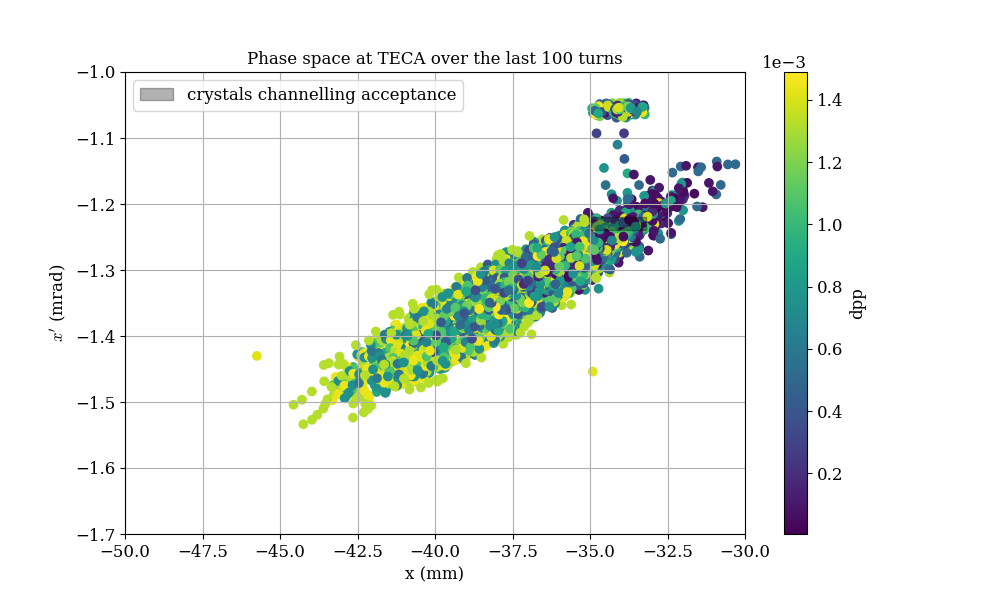

In [620]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for turn in range(100):
    sc = ax.scatter(
        row_TECA_exit['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TECA_exit['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
plt.colorbar(sc, label='dpp')

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')


#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')

ax.set_title("Phase space at TECA over the last 100 turns")
ax.legend()
ax.grid(True)

ax.set_xlim(-50, -30)
ax.set_ylim(-1.7, -1)

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.pdf', bbox_inches='tight')

## Phase space at TECA

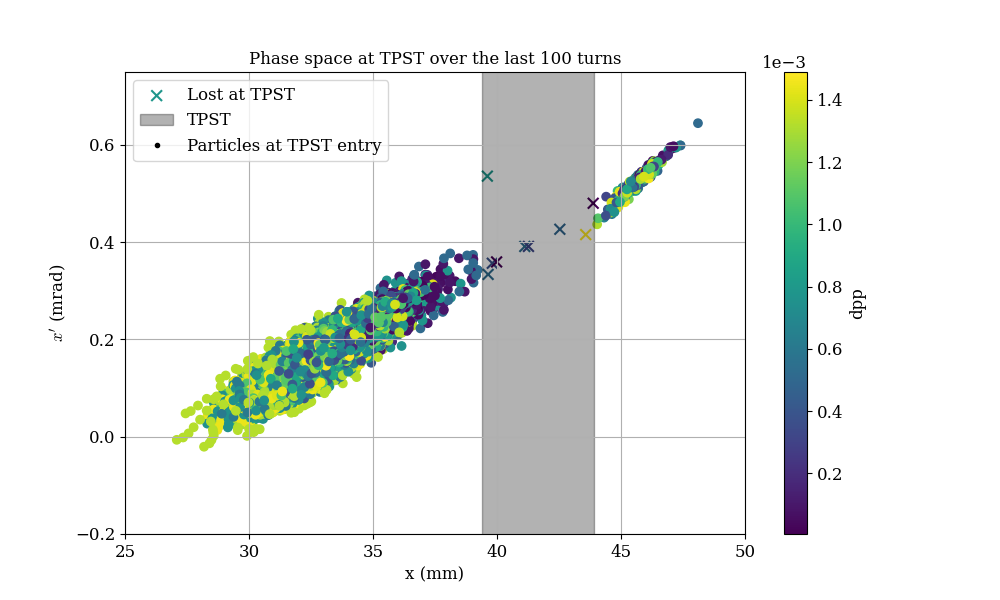

In [621]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TPST_entry = tw_lss2_df.loc['tpst.21760_entry']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

#ax.plot(row_TPST_entry['monitors'].x[:, :] * 1e3, row_TPST_entry['monitors'].px[:, :] * 1e3, 'k.', alpha=0.5)
for turn in range(100):
    sc = ax.scatter(
        row_TPST_entry['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TPST_entry['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
plt.colorbar(sc, label='dpp')

# Plot the particles lost at tpst.21760_entry.sep
if lost_at_tpst:
    ax.scatter(
        [particles.x[idx] * 1e3 for idx in lost_at_tpst],    # x in mm
        [particles.px[idx] * 1e3 for idx in lost_at_tpst],   # px in mrad
        c=[particles.delta[idx] for idx in lost_at_tpst],    # dpp for color
        cmap='viridis',
        marker='x',
        s=60,
        label='Lost at TPST'
    )

# Plot the particles lost at mst.21794.sep
if lost_at_mst:
    ax.scatter(
        [particles.x[idx] * 1e3 for idx in lost_at_mst],    # x in mm
        [particles.px[idx] * 1e3 for idx in lost_at_mst],   # px in mrad
        c=[particles.delta[idx] for idx in lost_at_mst],    # dpp for color
        cmap='viridis',
        marker='x',
        s=60,
        label='Lost at TPST'
    )


#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
element_name = 'tpst.21760_entry.sep'
x = line[element_name].interaction_process.blade_position
thickness = line[element_name].interaction_process.thickness
ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.3, label='TPST')

ax.plot([], [], 'k.', label='Particles at TPST entry')

ax.set_title("Phase space at TPST over the last 100 turns")

ax.legend()
ax.grid(True)

ax.set_xlim(25, 50)
ax.set_ylim(-0.2, 0.75)

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('tpst_phase_space.pdf', bbox_inches='tight')

# Animation of the phase space


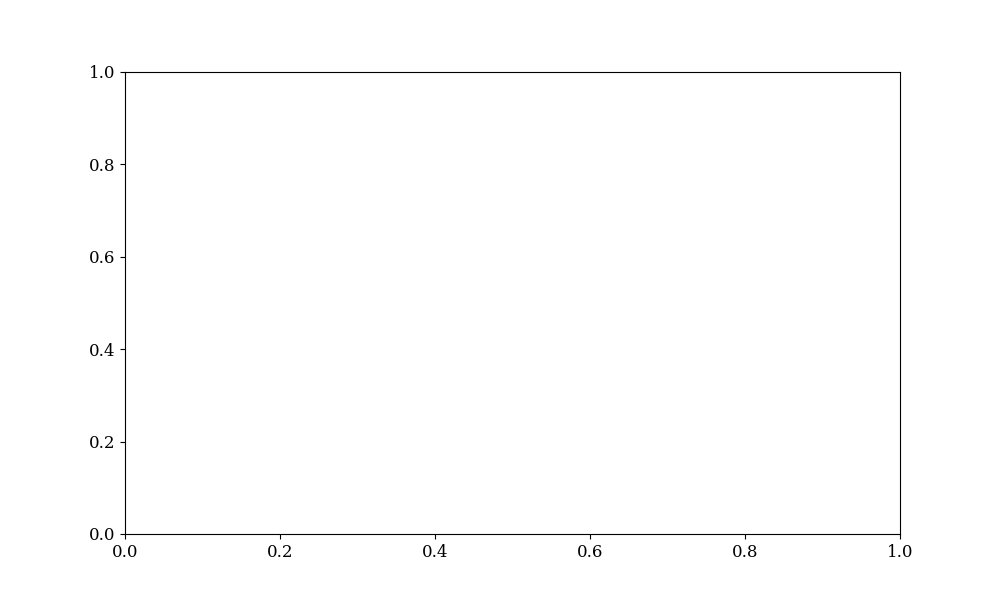

In [ ]:
# from matplotlib.animation import FuncAnimation
# import numpy as np

# import matplotlib.pyplot as plt

# # Create figure and axis
# fig, ax = plt.subplots(figsize=(10, 6))

# def update(frame):
#     ax.clear()
    
#     # Plot the phase space for the current turn
#     sc = ax.scatter(
#         row_TECA_exit['monitors'].x[:, frame] * 1e3,  # x position in mm
#         row_TECA_exit['monitors'].px[:, frame] * 1e3,  # px in mrad
#         c=particles_init._delta,  # Color by initial momentum deviation
#         cmap='viridis'
#     )
    
#     # Plot crystal position and acceptance
#     ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], 
#                     [TECA.tilt*1e3 - 10e-3]*2, 
#                     [TECA.tilt*1e3 + 10e-3]*2, 
#                     color='k', alpha=0.3, 
#                     label='Crystal acceptance')
    
#     # Set labels and title
#     ax.set_xlabel('x (mm)')
#     ax.set_ylabel(r"$x'$ (mrad)")
#     ax.set_title(f'Phase space at TECA - Turn {frame}')
    
#     # Set axis limits
#     ax.set_xlim(-50, -30)
#     ax.set_ylim(-1.7, -1)
    
#     ax.grid(True)
#     ax.legend()
    
#     return sc,

# # Create animation
# anim = FuncAnimation(fig, update, frames=num_turns, interval=100, blit=True)

# plt.show()